Root Mean Squared Error (RMSE): 64.79247028551829
Mean Absolute Error (MAE): 36.96496435022239


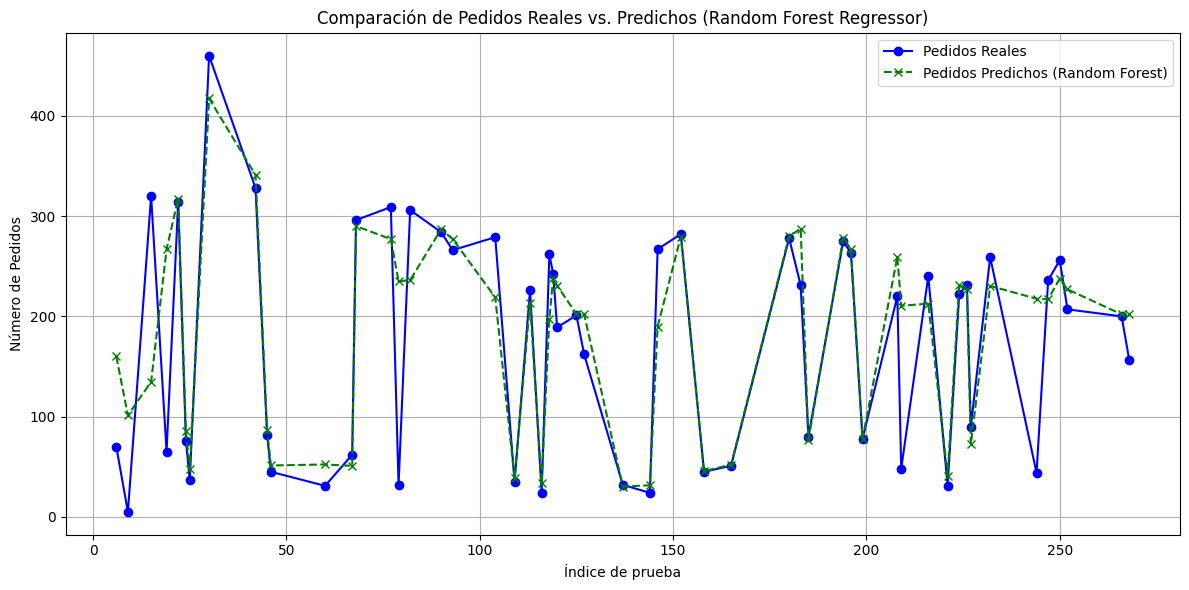

In [ ]:
# Importar bibliotecas necesarias
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Cargar los datos desde el archivo de Excel
file_path = 'ConteoDias.xlsx'  # Asegúrate de subir este archivo a Colab
data = pd.read_excel(file_path)

# Convertir la columna de fecha al formato datetime
data['fecha'] = pd.to_datetime(data['fecha'], errors='coerce')
data['day_of_week'] = data['fecha'].dt.dayofweek  # Extraer el día de la semana como característica

# Eliminar columnas irrelevantes para este modelo (ej: temperatura y viento)
data = data.drop(columns=['tavg', 'wspd'], errors='ignore')

# Crear características adicionales básicas
data['lluvia_alta'] = data['prcp'].apply(lambda x: 1 if x > 130 else 0)
data['orders_lag1'] = data['pedidos'].shift(1)  # Pedidos del día anterior
data['orders_lag2'] = data['pedidos'].shift(2)  # Pedidos de hace dos días

# Eliminar filas con valores nulos creados por el desplazamiento
data = data.dropna().reset_index(drop=True)

# Seleccionar las características relevantes para el modelo, incluyendo la fecha para visualización
X_features = data[['prcp', 'lluvia_alta', 'orders_lag1', 'orders_lag2', 'day_of_week']]
y = data['pedidos']

# División del conjunto de datos en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_features, y, test_size=0.2, random_state=42)

# Entrenar el modelo usando Random Forest
model = RandomForestRegressor(
    n_estimators=100,   # Número de árboles en el bosque
    max_depth=5,       # Profundidad máxima de los árboles
    random_state=42
)
model.fit(X_train, y_train)


# Predecir en el conjunto de prueba
y_pred = model.predict(X_test)

# Calcular métricas de error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")

# Combinar X_test y y_test en un DataFrame para ordenarlo por fecha
test_data = X_test.copy()
test_data['pedidos_reales'] = y_test.values
test_data['pedidos_predichos'] = y_pred
test_data = test_data.sort_index()  # Mantener el orden de las fechas en el conjunto de prueba

# Visualización de los resultados
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, test_data['pedidos_reales'], label="Pedidos Reales", marker='o', linestyle='-', color="blue")
plt.plot(test_data.index, test_data['pedidos_predichos'], label="Pedidos Predichos (Random Forest)", marker='x', linestyle='--', color="green")
plt.xlabel("Índice de prueba")
plt.ylabel("Número de Pedidos")
plt.title("Comparación de Pedidos Reales vs. Predichos (Random Forest Regressor)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [ ]:
import joblib

# Guardar el modelo entrenado
model_path = 'RandomForestPedidosDeManana.joblib'  # Nombre del archivo del modelo
joblib.dump(model, model_path)
print(f"Modelo guardado en: {model_path}")


Modelo guardado en: RandomForestPedidosDeManana.joblib
